Converting Llama 2 to Llama 3.2 From Scratch
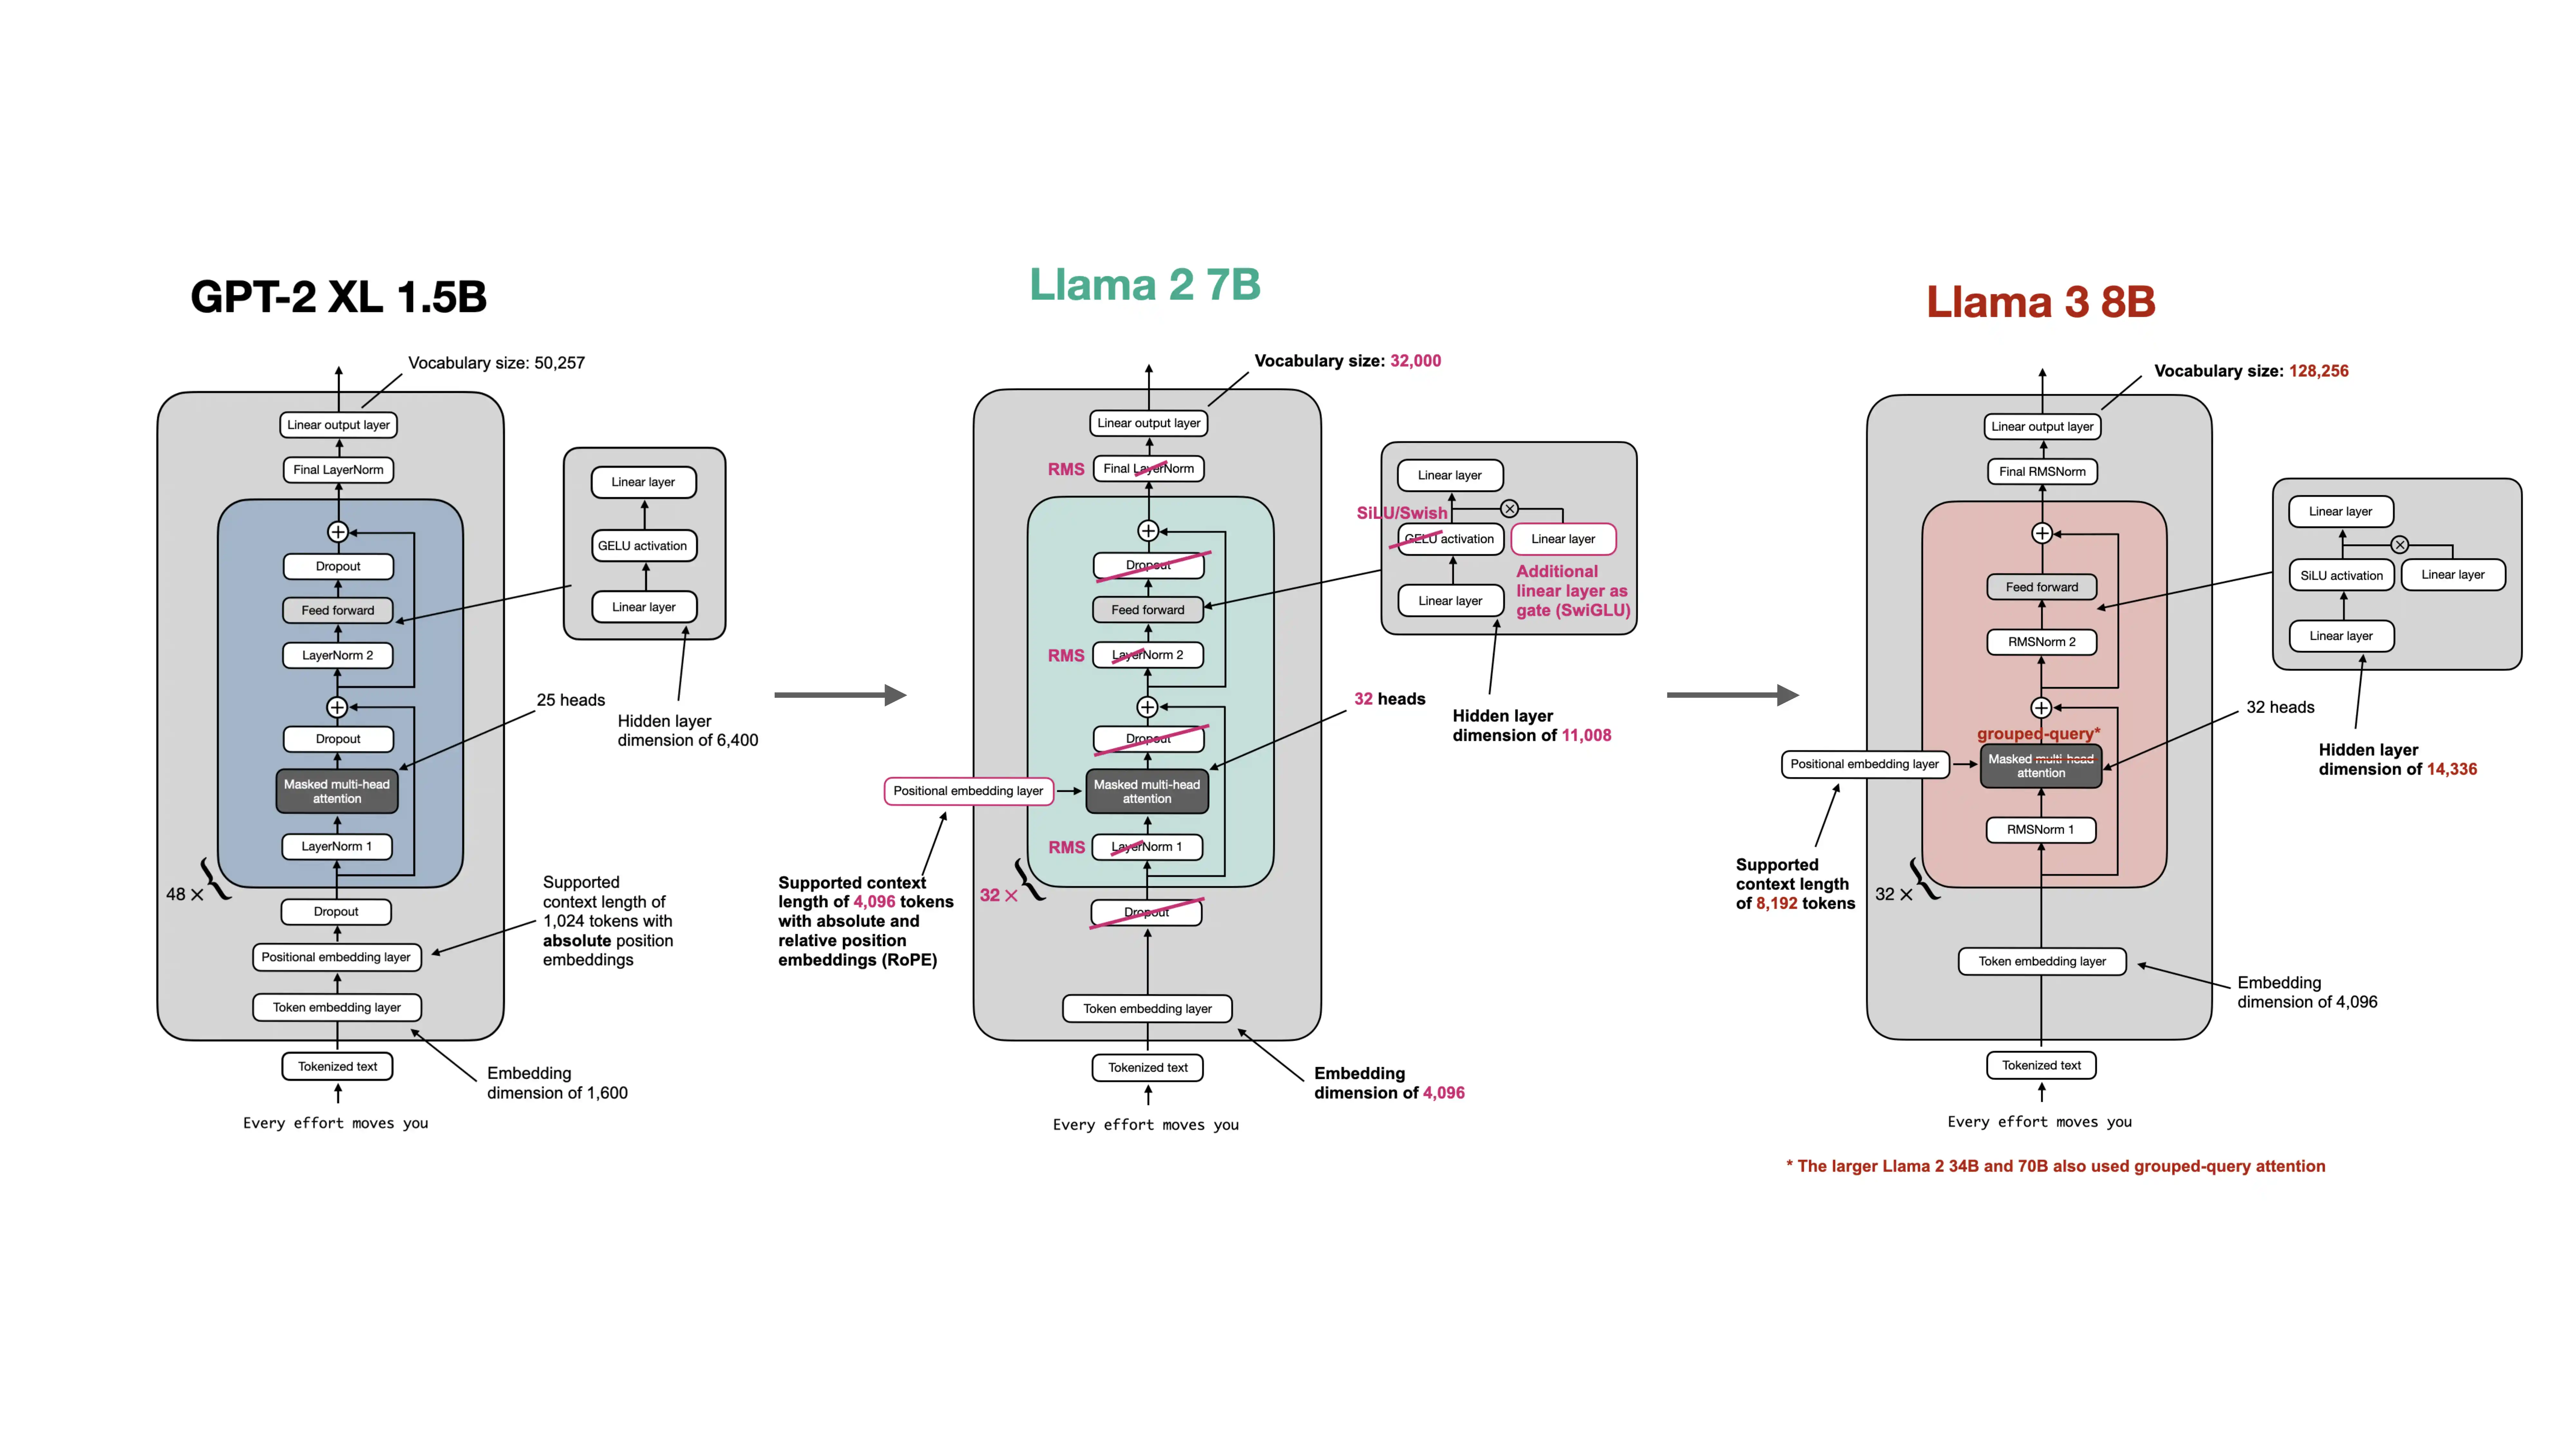

In [ ]:
# 检查/打印本 notebook 所需第三方库的版本：blobfile、huggingface_hub、matplotlib、tiktoken、torch
from importlib.metadata import version

pkgs = [
    "blobfile",         # to download pretrained weights
    "huggingface_hub",  # to download pretrained weights
    "matplotlib",       # to visualize RoPE with different base frequencies
    "tiktoken",         # to implement the tokenizer
    "torch",            # to implement the model
]
# 逐个打印已安装版本，便于确认运行环境是否满足实验要求
for p in pkgs:
    print(f"{p} version: {version(p)}")

1. Convert the Llama model implementation step by step
If you are new to implementing LLM architectures, I recommend starting with chapter 4, which walks you through the implementation of the original GPT architecture step by step
The Converting a From-Scratch GPT Architecture to Llama 2 then implements the Llama-specific components, such as RMSNorm layers, SiLU and SwiGLU activations, RoPE (rotary position embeddings), and the SentencePiece tokenizer
This notebook takes the Llama 2 architecture and transforms it into Llama 3 architecture by
modifying the rotary embeddings
implementing grouped-query attention
and using a customized version of the GPT-4 tokenizer
Later, we then load the original Llama 3 weights shared by Meta AI into the architecture


1.1 Reusing Llama 2 components
Llama 2 is actually quite similar to Llama 3, as mentioned above and illustrated in the figure at the top of this notebook
This means that we can import several building blocks from the Llama 2 notebook using the following code

In [ ]:
import os
import sys
import io
import nbformat
import types

# 从同目录下的 converting-gpt-to-llama2.ipynb 中动态导入 Llama2 阶段已经实现好的公共组件
# （RoPE 相关函数、SiLU、FeedForward、RMSNorm、MultiHeadAttention），避免在本 notebook 中重复实现。
# 提示：若已安装 llms_from_scratch 包，也可以直接 from llms_from_scratch.ch04 / ch05 导入这些组件。
def import_from_notebook():
    def import_definitions_from_notebook(fullname, names):
        current_dir = os.getcwd()
        path = os.path.join(current_dir, fullname + ".ipynb")
        path = os.path.normpath(path)

        # Load the notebook
        if not os.path.exists(path):
            raise FileNotFoundError(f"Notebook file not found at: {path}")

        with io.open(path, "r", encoding="utf-8") as f:
            nb = nbformat.read(f, as_version=4)

        # Create a module to store the imported functions and classes
        mod = types.ModuleType(fullname)
        sys.modules[fullname] = mod

        # Go through the notebook cells and only execute function or class definitions
        # 遍历目标 notebook 的所有代码单元，只执行其中包含目标函数/类定义的代码，
        # 其余代码（如下载权重、打印语句等）一律跳过，避免产生副作用
        for cell in nb.cells:
            if cell.cell_type == "code":
                cell_code = cell.source
                for name in names:
                    # Check for function or class definitions
                    if f"def {name}" in cell_code or f"class {name}" in cell_code:
                        exec(cell_code, mod.__dict__)
        return mod

    fullname = "converting-gpt-to-llama2"
    names = ["precompute_rope_params", "compute_rope", "SiLU", "FeedForward", "RMSNorm", "MultiHeadAttention"]

    return import_definitions_from_notebook(fullname, names)
# 执行导入，得到一个包含 Llama2 版本各组件的动态模块 imported_module
imported_module = import_from_notebook()

# We need to redefine precompute_rope_params
# precompute_rope_params = getattr(imported_module, "precompute_rope_params", None)
# 直接复用 Llama2 版本的 compute_rope（RoPE 的旋转计算逻辑，Llama3 并未改变这部分实现）
compute_rope = getattr(imported_module, "compute_rope", None)
SiLU = getattr(imported_module, "SiLU", None)
FeedForward = getattr(imported_module, "FeedForward", None)
RMSNorm = getattr(imported_module, "RMSNorm", None)

# MultiHeadAttention only for comparison purposes
MultiHeadAttention = getattr(imported_module, "MultiHeadAttention", None)

1.2 Modified RoPE
Llama 3 uses rotary position embeddings (RoPE) similar to Llama 2 (for a detailed explanation, please see the RoPE paper)
There are some subtle differences in the RoPE settings, though
Llama 3 now supports up to 8,192 tokens, twice as many as Llama 2 (4,096)
The base value for the so-called RoPE
 (see equation below) was increased from 10,000 (Llama 2) to 500,000 (Llama 3) in the following equation (adapted from the RoPE paper)


These
 values are a set of predefined parameters that are used to determine the rotational angles in the rotary matrix, where
 is the dimensionality of the embedding space
Increasing the base from 10,000 to 500,000 makes the frequencies decay faster across the dimensions, which means that the higher-dimensional components are associated with smaller rotation angles than before, so the overall frequency range becomes more compressed rather than expanded

In [ ]:
# 对比 Llama2 与 Llama3 的 RoPE 频率基数（theta base）：Llama2 用 10,000，Llama3 提高到 500,000
import matplotlib.pyplot as plt
import torch

# 演示用的注意力头维度 head_dim，需为偶数，因为 RoPE 是按维度两两一组做旋转的
d = 128
i = torch.arange(1, d // 2 + 1)

# RoPE 的底数（theta base）：值越大，随维度索引增长时旋转角度衰减得越慢，
# 等价于让模型在更长的上下文长度上仍能有效区分不同位置
base_llama2 = 10_000
base_llama3 = 500_000

# theta_i = base^(-2(i-1)/d)，i 取 1..d/2，对应公式中每一对维度上的旋转频率
theta_llama2 = base_llama2 ** (-2 * (i - 1) / d)
theta_llama3 = base_llama3 ** (-2 * (i - 1) / d)

# 绘图对比：base 越大（Llama3），高维度索引处的频率衰减越平缓，即高频信息保留到更靠后的维度
plt.plot(i, theta_llama2, label="base = 10,000 (Llama 2)")
plt.plot(i, theta_llama3, label="base = 500,000 (Llama 3)", ls="--")
plt.xlabel("dimension index i (1 … d/2)")
plt.ylabel(r"$\theta_i = \mathrm{base}^{-2(i-1)/d}$")
plt.legend()
plt.tight_layout()

In [ ]:
import torch

# 计算 RoPE 的 cos/sin 查找表。相比 Llama2/Llama3(8B 初版)，
# 这里新增了 freq_config 参数，用于 Llama3.1/3.2 的长上下文频率缩放（NTK-aware 风格调整）
def precompute_rope_params(head_dim, theta_base=10_000, context_length=4096, freq_config=None):
    assert head_dim % 2 == 0, "Embedding dimension must be even"

    # Compute the inverse frequencies
    # 基础反频率：inv_freq[i] = 1 / theta_base^(2i/head_dim)，形状为 (head_dim // 2,)
    inv_freq = 1.0 / (theta_base ** (torch.arange(0, head_dim, 2)[: (head_dim // 2)].float() / head_dim))

    ################################ NEW ###############################################
    # Frequency adjustments
    # 以下频率缩放逻辑是 Llama3.1/3.2 相对 Llama3(8B 初版)新增的改动：
    # 把原本按 8192 上下文训练得到的 RoPE 频率，重新缩放后外推到 131072 的长上下文
    if freq_config is not None:
        # 波长较长（低频）的维度除以 factor 做降频，避免长距离位置编码周期性重复导致位置混淆
        low_freq_wavelen = freq_config["original_context_length"] / freq_config["low_freq_factor"]
        high_freq_wavelen = freq_config["original_context_length"] / freq_config["high_freq_factor"]

        # 把频率换算成波长，方便与 original_context_length 比较，从而判断该维度属于低频/高频/过渡区
        wavelen = 2 * torch.pi / inv_freq

        # 波长大于 low_freq_wavelen 的维度（低频维度）按 factor 缩小频率
        inv_freq_llama = torch.where(
            wavelen > low_freq_wavelen, inv_freq / freq_config["factor"], inv_freq
        )

        # 对处于高低频之间的维度做线性插值（平滑过渡），避免频率缩放出现突变
        smooth_factor = (freq_config["original_context_length"] / wavelen - freq_config["low_freq_factor"]) / (
            freq_config["high_freq_factor"] - freq_config["low_freq_factor"]
        )

        smoothed_inv_freq = (
            (1 - smooth_factor) * (inv_freq / freq_config["factor"]) + smooth_factor * inv_freq
        )

        # 中间频段维度使用平滑插值后的频率，其余维度沿用前面 torch.where 得到的结果
        is_medium_freq = (wavelen <= low_freq_wavelen) & (wavelen >= high_freq_wavelen)
        inv_freq_llama = torch.where(is_medium_freq, smoothed_inv_freq, inv_freq_llama)
        inv_freq = inv_freq_llama
    ####################################################################################


    # Generate position indices
    # 生成 0 ~ context_length-1 的位置索引
    positions = torch.arange(context_length)

    # Compute the angles
    angles = positions.unsqueeze(1) * inv_freq.unsqueeze(0)  # Shape: (context_length, head_dim // 2)

    # Expand angles to match the head_dim
    angles = torch.cat([angles, angles], dim=1)  # Shape: (context_length, head_dim)

    # Precompute sine and cosine
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin

In [ ]:
# 记录 Llama2 与 Llama3(8B 初版) 两个版本的上下文长度与 RoPE theta 基数，用于下面的对比实验
# Instantiate RoPE parameters

llama_2_context_len = 4096
llama_3_context_len = 8192

llama_2_theta_base = 10_000
llama_3_theta_base = 500_000

In [ ]:
# 用随机张量演示 RoPE 的实际应用：batch_size=2, num_heads=4, head_dim=16
# Settings
batch_size = 2
num_heads = 4
head_dim = 16

# Instantiate RoPE parameters
# 使用 Llama3 的 theta_base=500,000、context_length=8192 生成 cos/sin 表，形状均为 (context_length, head_dim)
cos, sin = precompute_rope_params(
    head_dim=head_dim,
    theta_base=llama_3_theta_base,
    context_length=llama_3_context_len
)

# Dummy query and key tensors
# 构造随机 query/key 张量，形状为 (batch, num_heads, seq_len, head_dim)，模拟真实前向传播中的张量形状
torch.manual_seed(123)
queries = torch.randn(batch_size, num_heads, llama_3_context_len, head_dim)
keys = torch.randn(batch_size, num_heads, llama_3_context_len, head_dim)

# Apply rotary position embeddings
# compute_rope 按最后一维对 (batch, num_heads, seq_len, head_dim) 做旋转，输出形状保持不变
queries_rot = compute_rope(queries, cos, sin)
keys_rot = compute_rope(keys, cos, sin)

1.3 Grouped-query attention
In this section, we replace multi-head attention (MHA) with an alternative mechanism called grouped-query attention (GQA)
In short, one can think of GQA as a more compute- and parameter-efficient version of MHA
In GQA, we reduce the number of key and value projections by sharing them among multiple attention heads
Each attention head still has its unique query, but these queries attend to the same group of keys and values
Below is an illustration of GQA with 2 key-value-groups (kv-groups):

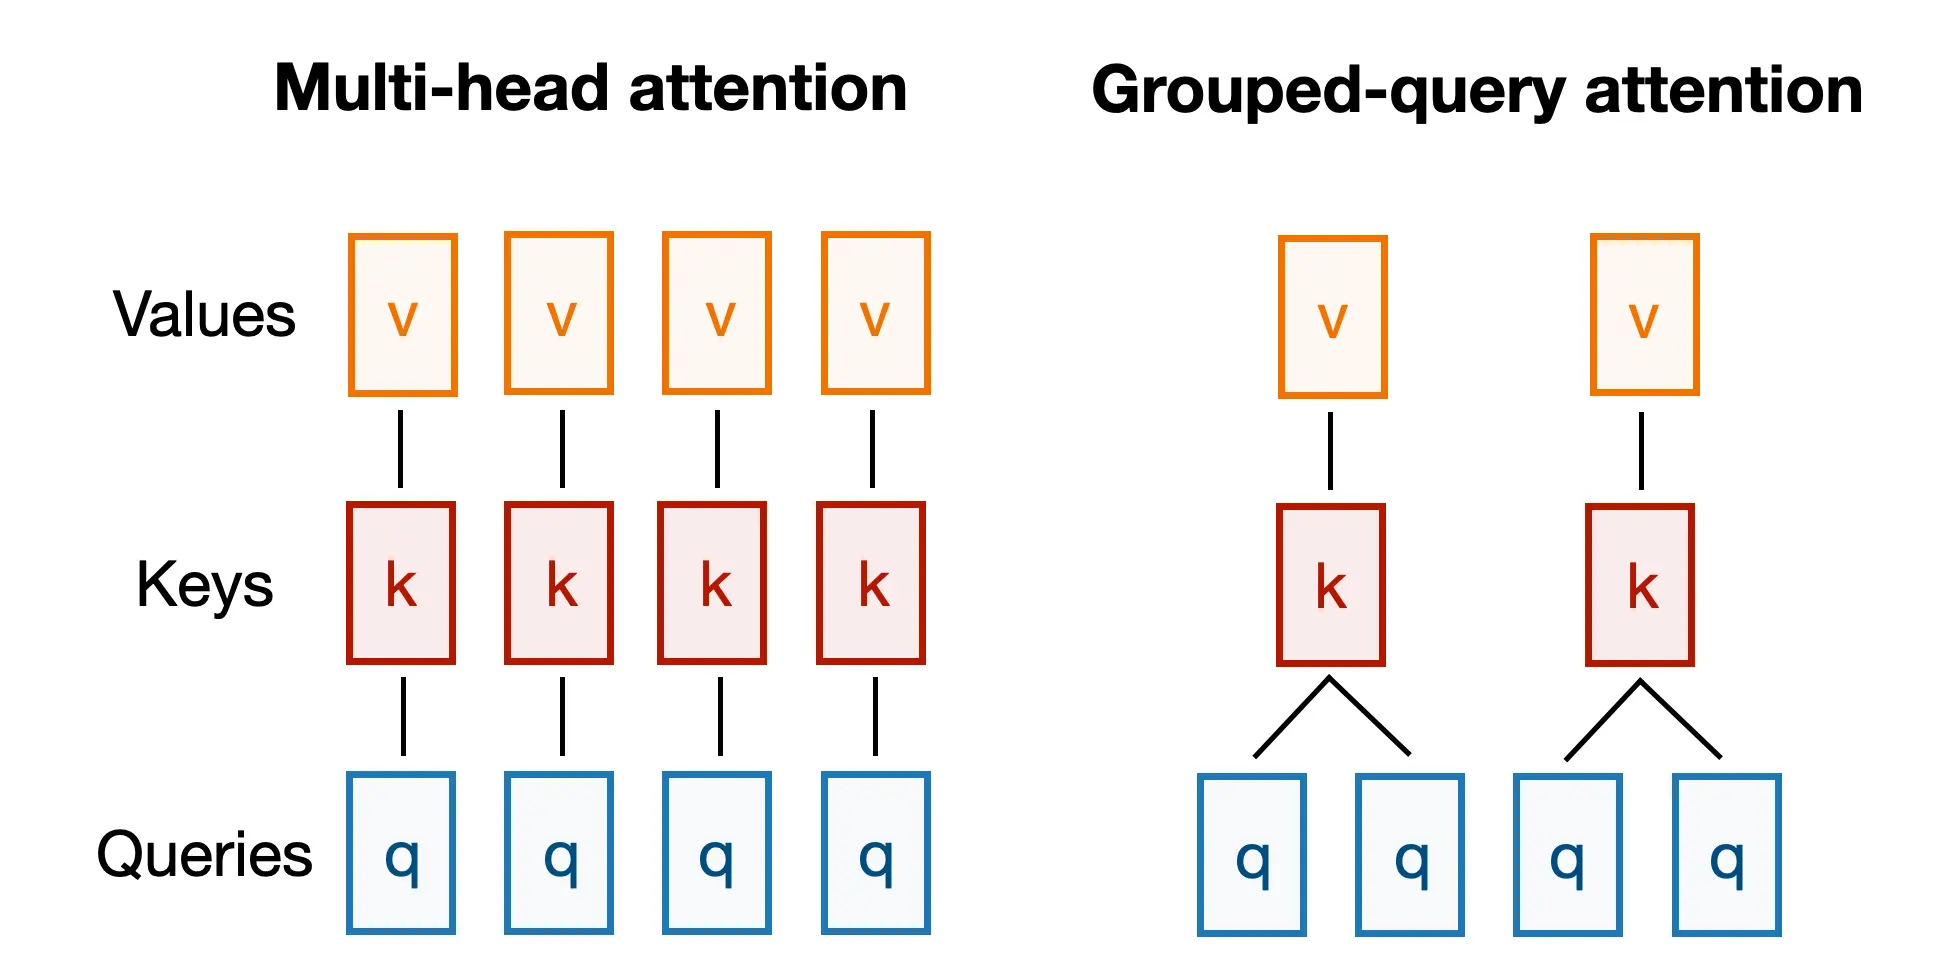

In [ ]:
import torch.nn as nn


# 分组查询注意力（GQA）：相对 Llama2 使用的多头注意力（MultiHeadAttention），
# Key/Value 的头数量被压缩为更少的 num_kv_groups 组，多个 Query 头共享同一组 K/V，
# 从而显著减少推理时 KV Cache 的显存占用
class GroupedQueryAttention(nn.Module):
    def __init__(
            self, d_in, d_out, num_heads,
            # 新增参数：KV 分组数量，需能整除 num_heads；每 (num_heads // num_kv_groups) 个 Query 头共享一组 K/V
            num_kv_groups,       # NEW
            dtype=None
        ):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        assert num_heads % num_kv_groups == 0, "num_heads must be divisible by num_kv_groups"  # NEW

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        ############################# NEW  #############################
        # 对比：Llama2 的写法（下方两行注释）让 W_key/W_value 的输出维度与 W_query 一致（每个头独立的 K/V）；
        # Llama3 的 GQA 让 W_key/W_value 只输出 num_kv_groups * head_dim 维，参数量显著减少
        # self.W_key = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        # self.W_value = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.W_key = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        self.W_value = nn.Linear(d_in, num_kv_groups * self.head_dim, bias=False, dtype=dtype)
        # 保存分组数 num_kv_groups，以及每组要被多少个 Query 头共享（group_size）
        self.num_kv_groups = num_kv_groups
        self.group_size = num_heads // num_kv_groups
        ################################################################

        self.W_query = nn.Linear(d_in, d_out, bias=False, dtype=dtype)
        self.out_proj = nn.Linear(d_out, d_out, bias=False, dtype=dtype)


    # 前向传播新增 mask、cos、sin 作为显式参数（而不是像 Llama2 里存成 self 属性），
    # 便于在不同调用之间灵活传入不同长度的 mask 和不同的 RoPE 参数
    def forward(self, x, mask=None, cos=None, sin=None):
        ##################### NEW  #####################
        # The forward method now accepts `mask` instead of accessing it via self.mask.
        # Also, we now have cos and sin as input for RoPE
        ################################################
        b, num_tokens, d_in = x.shape

        # queries: (b, num_tokens, d_out)；keys/values 只投影到 num_kv_groups * head_dim 维，而非完整的 d_out 维
        queries = self.W_query(x)  # Shape: (b, num_tokens, d_out)
        keys = self.W_key(x)  # Shape: (b, num_tokens, num_kv_groups * head_dim)
        values = self.W_value(x)  # Shape: (b, num_tokens, num_kv_groups * head_dim)

        # Reshape queries, keys, and values
        # 将 queries 拆分为 num_heads 个独立的头：(b, num_tokens, num_heads, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        ##################### NEW  #####################
        # keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        # values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        # keys/values 按 num_kv_groups（而非 num_heads）拆分头：(b, num_tokens, num_kv_groups, head_dim)
        keys = keys.view(b, num_tokens, self.num_kv_groups, self.head_dim)
        values = values.view(b, num_tokens, self.num_kv_groups, self.head_dim)
        ################################################

        # Transpose keys, values, and queries
        keys = keys.transpose(1, 2)  # Shape: (b, num_kv_groups, num_tokens, head_dim)
        values = values.transpose(1, 2)  # Shape: (b, num_kv_groups, num_tokens, head_dim)
        queries = queries.transpose(1, 2)  # Shape: (b, num_heads, num_tokens, head_dim)

        ##################### NEW #####################
        # Apply RoPE
        # 对 keys 和 queries 施加 RoPE 旋转位置编码：在分组阶段之后、复制扩展之前进行，
        # 这样每个 K/V 分组只需要计算一次旋转，而不是重复计算 num_heads 次
        if cos is not None:
            keys = compute_rope(keys, cos, sin)
            queries = compute_rope(queries, cos, sin)
        ################################################

        ##################### NEW  #####################
        # Expand keys and values to match the number of heads
        # Shape: (b, num_heads, num_tokens, head_dim)

        # GQA 的核心步骤：把每组 K/V 沿头维度重复 group_size 次，数值上广播回 num_heads 份，
        # 使后续的注意力矩阵乘法与标准多头注意力保持一致的张量形状 (b, num_heads, num_tokens, head_dim)
        keys = keys.repeat_interleave(self.group_size, dim=1)  # Shape: (b, num_heads, num_tokens, head_dim)
        values = values.repeat_interleave(self.group_size, dim=1)  # Shape: (b, num_heads, num_tokens, head_dim)
        # For example, before repeat_interleave along dim=1 (query groups):
        #   [K1, K2]
        # After repeat_interleave (each query group is repeated group_size times):
        #   [K1, K1, K2, K2]
        # If we used regular repeat instead of repeat_interleave, we'd get:
        #   [K1, K2, K1, K2]
        ################################################

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        # Shape: (b, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        ##################### NEW #####################
        # Create mask on the fly
        if mask is None:
            mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)
        ################################################

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        assert keys.shape[-1] == self.head_dim

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [ ]:
# 用更接近真实 Llama 规模的例子（embed_dim=4096, num_heads=32）对比标准多头注意力（MHA）
# 与分组查询注意力（GQA）的参数量差异
# Settings
batch_size = 1
context_len = 3000
max_context_len = 8192
embed_dim = 4096
num_heads = 32


example_batch = torch.randn((batch_size, context_len, embed_dim))

# 标准 MHA：W_key/W_value 的输出维度与 W_query 相同，即每个头都有独立的 K/V 投影
mha = MultiHeadAttention(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=max_context_len,
    num_heads=num_heads
)

mha(example_batch)

# 可以看到 W_key/W_value 权重矩阵形状为 (embed_dim, embed_dim)，即 4096x4096
print("W_key:", mha.W_key.weight.shape)
print("W_value:", mha.W_value.weight.shape)
print("W_query:", mha.W_query.weight.shape)

In [ ]:
# 用相同的 embed_dim/num_heads，但设置 num_kv_groups=8：32 个 Query 头，每 4 个共享一组 K/V
gqa = GroupedQueryAttention(
    d_in=embed_dim,
    d_out=embed_dim,
    num_heads=num_heads,
    num_kv_groups=8,
)

gqa(example_batch)

# W_key/W_value 权重矩阵形状缩小为 (num_kv_groups*head_dim, embed_dim) = (8*128, 4096)，远小于 MHA 的 4096x4096
print("W_key:", gqa.W_key.weight.shape)
print("W_value:", gqa.W_value.weight.shape)
print("W_query:", gqa.W_query.weight.shape)

In [ ]:
# 对比 MHA 与 GQA 的总参数量，直观展示 GQA 在 K/V 投影上节省的参数量
print("Total number of parameters:")

mha_total_params = sum(p.numel() for p in mha.parameters())
print(f"MHA: {mha_total_params:,}")

gqa_total_params = sum(p.numel() for p in gqa.parameters())
print(f"GQA: {gqa_total_params:,}")

In [ ]:
# 释放示例用的 MHA/GQA 模块，避免占用显存/内存影响后续实验
# Free up memory:
del mha
del gqa

1.4 Update the TransformerBlock module

In [ ]:
# Llama3 的 TransformerBlock：把注意力模块由 MultiHeadAttention 换成 GroupedQueryAttention，
# 并新增 n_kv_groups 配置项
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att =  GroupedQueryAttention(  # MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            num_heads=cfg["n_heads"],
            # 从配置中读取 KV 分组数，实现 GQA
            num_kv_groups=cfg["n_kv_groups"],  # NEW
            dtype=cfg["dtype"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = RMSNorm(cfg["emb_dim"], eps=1e-5)
        self.norm2 = RMSNorm(cfg["emb_dim"], eps=1e-5)

    # 前向传播中，mask/cos/sin 由外层的 Llama3Model 统一计算好后逐层传入，各层共享同一份
    def forward(self, x, mask=None, cos=None, sin=None):
        ##################### NEW  #####################
        # The forward method now accepts `mask` instead of accessing it via self.mask.
        # Also, we now have cos and sin as input for RoPE
        ################################################
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x.to(torch.bfloat16), mask, cos, sin)   # Shape [batch_size, num_tokens, emb_size]
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed-forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x.to(torch.bfloat16))
        x = x + shortcut  # Add the original input back

        return x

1.5 Defining the model class

In [ ]:
# 与 Llama2Model 相比，模型整体结构不变（词嵌入 -> N 层 TransformerBlock -> RMSNorm -> 输出头），
# 核心区别在于：TransformerBlock 内部换成了 GQA，且本类会预先计算好 RoPE 的 cos/sin 并注册为 buffer
# class Llama2Model(nn.Module):
class Llama3Model(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"], dtype=cfg["dtype"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = RMSNorm(cfg["emb_dim"], eps=1e-5)
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False, dtype=cfg["dtype"])

        #################### NEW #####################
        # 依据配置里的 rope_base（Llama3 提高到 500,000）、context_length，
        # 以及可选的 rope_freq（长上下文频率缩放，Llama3.1/3.2 使用）预先计算好 RoPE 的 cos/sin 表
        cos, sin = precompute_rope_params(
            head_dim=cfg["emb_dim"] // cfg["n_heads"],
            theta_base=cfg["rope_base"],
            context_length=cfg["context_length"],
            freq_config=cfg["rope_freq"]
        )

        # 注册为非持久化 buffer：会随模型一起搬到 GPU/CPU，但不会被保存进 state_dict/checkpoint（可按需重新计算）
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        ##############################################

        self.cfg = cfg

    def forward(self, in_idx):
        tok_embeds = self.tok_emb(in_idx)
        x = tok_embeds

        #################### NEW #####################
        # 每次前向传播都根据当前输入长度动态构造因果 mask（下三角遮罩），
        # 避免为固定的最大上下文长度预先分配整张 mask
        num_tokens = x.shape[1]
        mask = torch.triu(torch.ones(num_tokens, num_tokens, device=x.device, dtype=torch.bool), diagonal=1)
        ##############################################

        # 逐层将同一份 mask、cos、sin 传给每个 TransformerBlock
        for block in self.trf_blocks:
            x = block(x, mask, self.cos, self.sin)
        x = self.final_norm(x)
        logits = self.out_head(x.to(self.cfg["dtype"]))
        return logits

2. Initialize model

In [ ]:
# Llama2-7B 配置：词表 32,000，上下文 4096，RoPE theta 基数为默认的 10,000，且不使用 GQA
LLAMA2_CONFIG_7B = {
    "vocab_size": 32_000,    # Vocabulary size
    "context_length": 4096,  # Context length
    "emb_dim": 4096,         # Embedding dimension
    "n_heads": 32,           # Number of attention heads
    "n_layers": 32,          # Number of layers
    "hidden_dim": 11_008,    # Size of the intermediate dimension in FeedForward
    "dtype": torch.bfloat16  # Lower-precision dtype to reduce memory usage
}
# Llama3-8B（初版）配置：词表扩大到 128,256，上下文翻倍到 8192，
# FeedForward 隐藏维度增大到 14,336，新增 n_kv_groups=8 实现 GQA，
# RoPE theta 基数提升到 500,000，rope_freq 为 None 表示不做长上下文频率缩放
LLAMA3_CONFIG_8B = {
    "vocab_size": 128_256,   # NEW: Larger vocabulary size
    "context_length": 8192,  # NEW: Larger context length
    "emb_dim": 4096,         # Embedding dimension
    "n_heads": 32,           # Number of attention heads
    "n_layers": 32,          # Number of layers
    "hidden_dim": 14_336,    # NEW: Larger size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,        # NEW: Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,  # NEW: The base in RoPE's "theta" was increased to 500_000
    "rope_freq": None,       # NEW: Additional configuration for adjusting the RoPE frequencies
    "dtype": torch.bfloat16  # Lower-precision dtype to reduce memory usage
}

In [ ]:
# 用 Llama3-8B 配置实例化模型
model = Llama3Model(LLAMA3_CONFIG_8B)

In [ ]:
# 统计模型总参数量（Llama3-8B 约为 80 亿参数）
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

In [ ]:
# 估算模型在给定 dtype 下所需的显存/内存：包含参数本身、（若需要）同等大小的梯度、以及 buffer（如 RoPE 的 cos/sin）
def calc_model_memory_size(model, input_dtype=torch.float32):
    total_params = 0
    total_grads = 0
    for param in model.parameters():
        # Calculate total number of elements per parameter
        param_size = param.numel()
        total_params += param_size
        # Check if gradients are stored for this parameter
        if param.requires_grad:
            total_grads += param_size

    # Calculate buffer size (non-parameters that require memory)
    total_buffers = sum(buf.numel() for buf in model.buffers())

    # Size in bytes = (Number of elements) * (Size of each element in bytes)
    # We assume parameters and gradients are stored in the same type as input dtype
    element_size = torch.tensor(0, dtype=input_dtype).element_size()
    total_memory_bytes = (total_params + total_grads + total_buffers) * element_size

    # Convert bytes to gigabytes
    total_memory_gb = total_memory_bytes / (1024**3)

    return total_memory_gb

# 对比 float32 与 bfloat16 两种精度下的内存占用，体现使用 bfloat16 可将显存需求降低约一半
print(f"float32 (PyTorch default): {calc_model_memory_size(model, input_dtype=torch.float32):.2f} GB")
print(f"bfloat16: {calc_model_memory_size(model, input_dtype=torch.bfloat16):.2f} GB")

In [ ]:
# 自动选择可用的计算设备：优先 CUDA GPU，其次 Apple Silicon 的 MPS，最后回退到 CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device);

3. Load tokenizer

In [ ]:
# Llama3 换用了基于 tiktoken 的 BPE 分词器（而非 Llama2 的 SentencePiece），
# 词表规模从 32,000 扩大到 128,256，并新增了一批用于对话格式的特殊 token
from pathlib import Path

import tiktoken
from tiktoken.load import load_tiktoken_bpe


class Tokenizer:
    """Thin wrapper around tiktoken that keeps track of Llama-3 special IDs."""
    def __init__(self, model_path):
        if not os.path.isfile(model_path):
            raise FileNotFoundError(model_path)

        mergeable = load_tiktoken_bpe(model_path)

        # hard-coded from Meta's tokenizer.json
        # 硬编码 Llama3 官方 tokenizer.json 中定义的特殊 token id（文本起止符、对话头部标记等）
        self.special = {
            "<|begin_of_text|>": 128000,
            "<|end_of_text|>": 128001,
            "<|start_header_id|>": 128006,
            "<|end_header_id|>": 128007,
            "<|eot_id|>": 128009,
        }
        # 补充 256 个保留位特殊 token（reserved），占据剩余的 token id 区间，凑够 Llama3 完整的 128,256 词表大小
        self.special.update({f"<|reserved_{i}|>": 128002 + i
                             for i in range(256)
                             if 128002 + i not in self.special.values()})

        # 使用与官方一致的正则切分规则（pat_str）和 BPE 合并规则（mergeable_ranks）构造 tiktoken 编码器
        self.model = tiktoken.Encoding(
            name=Path(model_path).name,
            pat_str=r"(?i:'s|'t|'re|'ve|'m|'ll|'d)"
                    r"|[^\r\n\p{L}\p{N}]?\p{L}+"
                    r"|\p{N}{1,3}"
                    r"| ?[^\s\p{L}\p{N}]+[\r\n]*"
                    r"|\s*[\r\n]+"
                    r"|\s+(?!\S)"
                    r"|\s+",
            mergeable_ranks=mergeable,
            special_tokens=self.special,
        )

    # bos/eos 控制是否在编码结果前后添加起止特殊 token
    def encode(self, text, bos=False, eos=False):
        ids = ([self.special["<|begin_of_text|>"]] if bos else []) \
              + self.model.encode(text)
        if eos:
            ids.append(self.special["<|end_of_text|>"])
        return ids

    def decode(self, ids):
        return self.model.decode(ids)

In [ ]:
# 从本地 config.json 读取 Hugging Face 访问令牌并登录：
# Llama3 系列模型是受限（gated）仓库，需要有权限的账号才能下载
from huggingface_hub import login
import json

with open("config.json", "r") as config_file:
    config = json.load(config_file)
    access_token = config["HF_ACCESS_TOKEN"]

login(token=access_token)

In [ ]:
# 下载 Meta-Llama-3-8B 官方仓库中的原始 tokenizer.model 文件（tiktoken 格式）
from huggingface_hub import hf_hub_download

tokenizer_file_path = hf_hub_download(
    repo_id="meta-llama/Meta-Llama-3-8B",
    filename="original/tokenizer.model",
    local_dir="Llama-3-8B"
)

In [ ]:
# 用下载好的 tokenizer.model 文件构造前面定义的 Tokenizer
tokenizer = Tokenizer(tokenizer_file_path)

In [ ]:
# 复用第 4/5 章实现的 generate、text_to_token_ids、token_ids_to_text 等工具函数
from previous_chapters import generate, text_to_token_ids, token_ids_to_text
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch05 import generate, text_to_token_ids, token_ids_to_text


# 用尚未加载预训练权重的随机初始化模型做一次生成，此时输出应为无意义的乱码，
# 这里仅用来验证前向传播链路（GQA + RoPE + mask）在张量形状上是通的
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=30,
    context_size=LLAMA3_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

4. Load pretrained weights

In [ ]:
# Meta-Llama-3-8B 的权重以 safetensors 格式分成 4 个分片文件发布，逐个下载后合并到一个字典里
from safetensors.torch import load_file

combined_weights = {}

for i in range(1, 5):
    weights_file = hf_hub_download(
        repo_id="meta-llama/Meta-Llama-3-8B",
        filename=f"model-0000{i}-of-00004.safetensors",
        local_dir="Llama-3-8B"
    )
    current_weights = load_file(weights_file)
    combined_weights.update(current_weights)

In [ ]:
# 查看权重字典的前 15 个 key，确认命名格式（如 model.layers.{l}.self_attn.q_proj.weight），便于后续按名称加载
list(combined_weights.keys())[:15]

In [ ]:
# 通用的权重拷贝函数：校验形状一致后，把右侧（HuggingFace 官方权重）的数据拷贝进左侧（自定义模型）的参数张量
def assign(left, right, tensor_name="unknown"):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch in tensor '{tensor_name}'. Left: {left.shape}, Right: {right.shape}")

    with torch.no_grad():
        if isinstance(right, torch.Tensor):
            left.copy_(right)
        else:
            left.copy_(torch.as_tensor(right, dtype=left.dtype, device=left.device))

    return left


# 按 HuggingFace 官方权重命名规则，把每一层的 q/k/v/o 投影、两个 RMSNorm、
# 以及 SwiGLU 的 gate/up/down 三个线性层权重逐一搬进自定义的 Llama3Model
def load_weights_into_llama(model, param_config, params):
    model.tok_emb.weight = assign(model.tok_emb.weight, params["model.embed_tokens.weight"], "model.embed_tokens.weight")

    for l in range(param_config["n_layers"]):

        # Load attention weights
        model.trf_blocks[l].att.W_query.weight = assign(
            model.trf_blocks[l].att.W_query.weight,
            params[f"model.layers.{l}.self_attn.q_proj.weight"],
            f"model.layers.{l}.self_attn.q_proj.weight"
        )
        model.trf_blocks[l].att.W_key.weight = assign(
            model.trf_blocks[l].att.W_key.weight,
            params[f"model.layers.{l}.self_attn.k_proj.weight"],
            f"model.layers.{l}.self_attn.k_proj.weight"
        )
        model.trf_blocks[l].att.W_value.weight = assign(
            model.trf_blocks[l].att.W_value.weight,
            params[f"model.layers.{l}.self_attn.v_proj.weight"],
            f"model.layers.{l}.self_attn.v_proj.weight"
        )
        model.trf_blocks[l].att.out_proj.weight = assign(
            model.trf_blocks[l].att.out_proj.weight,
            params[f"model.layers.{l}.self_attn.o_proj.weight"],
            f"model.layers.{l}.self_attn.o_proj.weight"
        )
        model.trf_blocks[l].norm1.weight = assign(
            model.trf_blocks[l].norm1.weight,
            params[f"model.layers.{l}.input_layernorm.weight"],
            f"model.layers.{l}.input_layernorm.weight"
        )

        # Load FeedForward weights
        model.trf_blocks[l].ff.fc1.weight = assign(
            model.trf_blocks[l].ff.fc1.weight,
            params[f"model.layers.{l}.mlp.gate_proj.weight"],
            f"model.layers.{l}.mlp.gate_proj.weight"
        )
        model.trf_blocks[l].ff.fc2.weight = assign(
            model.trf_blocks[l].ff.fc2.weight,
            params[f"model.layers.{l}.mlp.up_proj.weight"],
            f"model.layers.{l}.mlp.up_proj.weight"
        )
        model.trf_blocks[l].ff.fc3.weight = assign(
            model.trf_blocks[l].ff.fc3.weight,
            params[f"model.layers.{l}.mlp.down_proj.weight"],
            f"model.layers.{l}.mlp.down_proj.weight"
        )
        model.trf_blocks[l].norm2.weight = assign(
            model.trf_blocks[l].norm2.weight,
            params[f"model.layers.{l}.post_attention_layernorm.weight"],
            f"model.layers.{l}.post_attention_layernorm.weight"
        )

    # Load output layer weights
    model.final_norm.weight = assign(model.final_norm.weight, params["model.norm.weight"], "model.norm.weight")

    # 部分 Llama3 变体（如 3.2-1B）采用权重绑定（weight tying），
    # 输出层与词嵌入共享同一份权重，因此权重文件中不单独存放 lm_head.weight
    if "lm_head.weight" in params.keys():
        model.out_head.weight = assign(model.out_head.weight, params["lm_head.weight"], "lm_head.weight")
    else:
        model.out_head.weight = model.tok_emb.weight
        print("Model uses weight tying.")


load_weights_into_llama(model, LLAMA3_CONFIG_8B, combined_weights)
model.to(device);
del combined_weights  # free up memory

In [ ]:
# 加载预训练权重后再次生成，此时应输出连贯、有意义的英文续写，用于验证权重加载是否正确
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA3_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

5. Using the instruction-finetuned model

In [ ]:
# to free up memory

import gc

del model

gc.collect()  # Run Python garbage collector

if torch.cuda.is_available():
    torch.cuda.empty_cache()
# 切换到 Instruct（指令微调）版本的权重：Meta-Llama-3-8B-Instruct，用于后续演示对话格式
combined_weights = {}

for i in range(1, 5):
    weights_file = hf_hub_download(
        repo_id="meta-llama/Meta-Llama-3-8B-Instruct",
        filename=f"model-0000{i}-of-00004.safetensors",
        local_dir="Llama-3-8B-Instruct"
    )
    current_weights = load_file(weights_file)
    combined_weights.update(current_weights)


model = Llama3Model(LLAMA3_CONFIG_8B)
load_weights_into_llama(model, LLAMA3_CONFIG_8B, combined_weights)
model.to(device)
del combined_weights  # free up memory

In [ ]:
# 实现 Llama3 官方的对话 prompt 模板：用 <|begin_of_text|>、
# <|start_header_id|>role<|end_header_id|>、<|eot_id|> 等特殊 token 包裹 system/user/assistant 三段内容
class ChatFormat:

    def __init__(self, tokenizer: Tokenizer, *,
                 default_system="You are a helpful assistant."):
        self.tok = tokenizer
        self.default_system = default_system

    def _header(self, role):
        """Encode <|start_header_id|>role<|end_header_id|>\n\n"""
        return (
            [self.tok.special["<|start_header_id|>"]]
            + self.tok.encode(role)
            + [self.tok.special["<|end_header_id|>"]]
            + self.tok.encode("\n\n")
        )

    # 依次拼接：起始符 -> system 段 -> user 段 -> assistant 段的起始头部（不含内容，留给模型续写）
    def encode(self, user_message, system_message=None):
        sys_msg = system_message if system_message is not None else self.default_system

        ids = [self.tok.special["<|begin_of_text|>"]]

        # system
        ids += self._header("system")
        ids += self.tok.encode(sys_msg)
        ids += [self.tok.special["<|eot_id|>"]]

        # user
        ids += self._header("user")
        ids += self.tok.encode(user_message)
        ids += [self.tok.special["<|eot_id|>"]]

        # assistant header (no content yet)
        ids += self._header("assistant")

        return ids

In [ ]:
# 用 Instruct 模型对应的 tokenizer 构造对话格式化器，并试编码一句简单问候，检查特殊 token 是否正确插入
tokenizer = Tokenizer(tokenizer_file_path)
chat_tokenizer = ChatFormat(tokenizer)

token_ids = chat_tokenizer.encode("Hello World!")
print(token_ids)

In [ ]:
# 解码回文本，肉眼检查特殊 token 与内容是否符合预期的对话模板格式
tokenizer.decode(token_ids)

In [ ]:
# 用 ChatFormat 编码问题后送入 Instruct 模型生成回答
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("What do llamas eat?", chat_tokenizer).to(device),
    max_new_tokens=150,
    context_size=LLAMA3_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

output_text = token_ids_to_text(token_ids, tokenizer)


# 生成结果里仍包含完整的 prompt 模板，这里从最后一个 assistant 头部之后截取，得到模型真正给出的回答内容
def clean_text(text, header_end="assistant<|end_header_id|>\n\n"):
    # Find the index of the first occurrence of "<|end_header_id|>"
    index = text.find(header_end)

    if index != -1:
        # Return the substring starting after "<|end_header_id|>"
        return text[index + len(header_end):].strip()  # Strip removes leading/trailing whitespace
    else:
        # If the token is not found, return the original text
        return text

print("Output text:\n", clean_text(output_text))

6. Llama 3.1 8B
7. 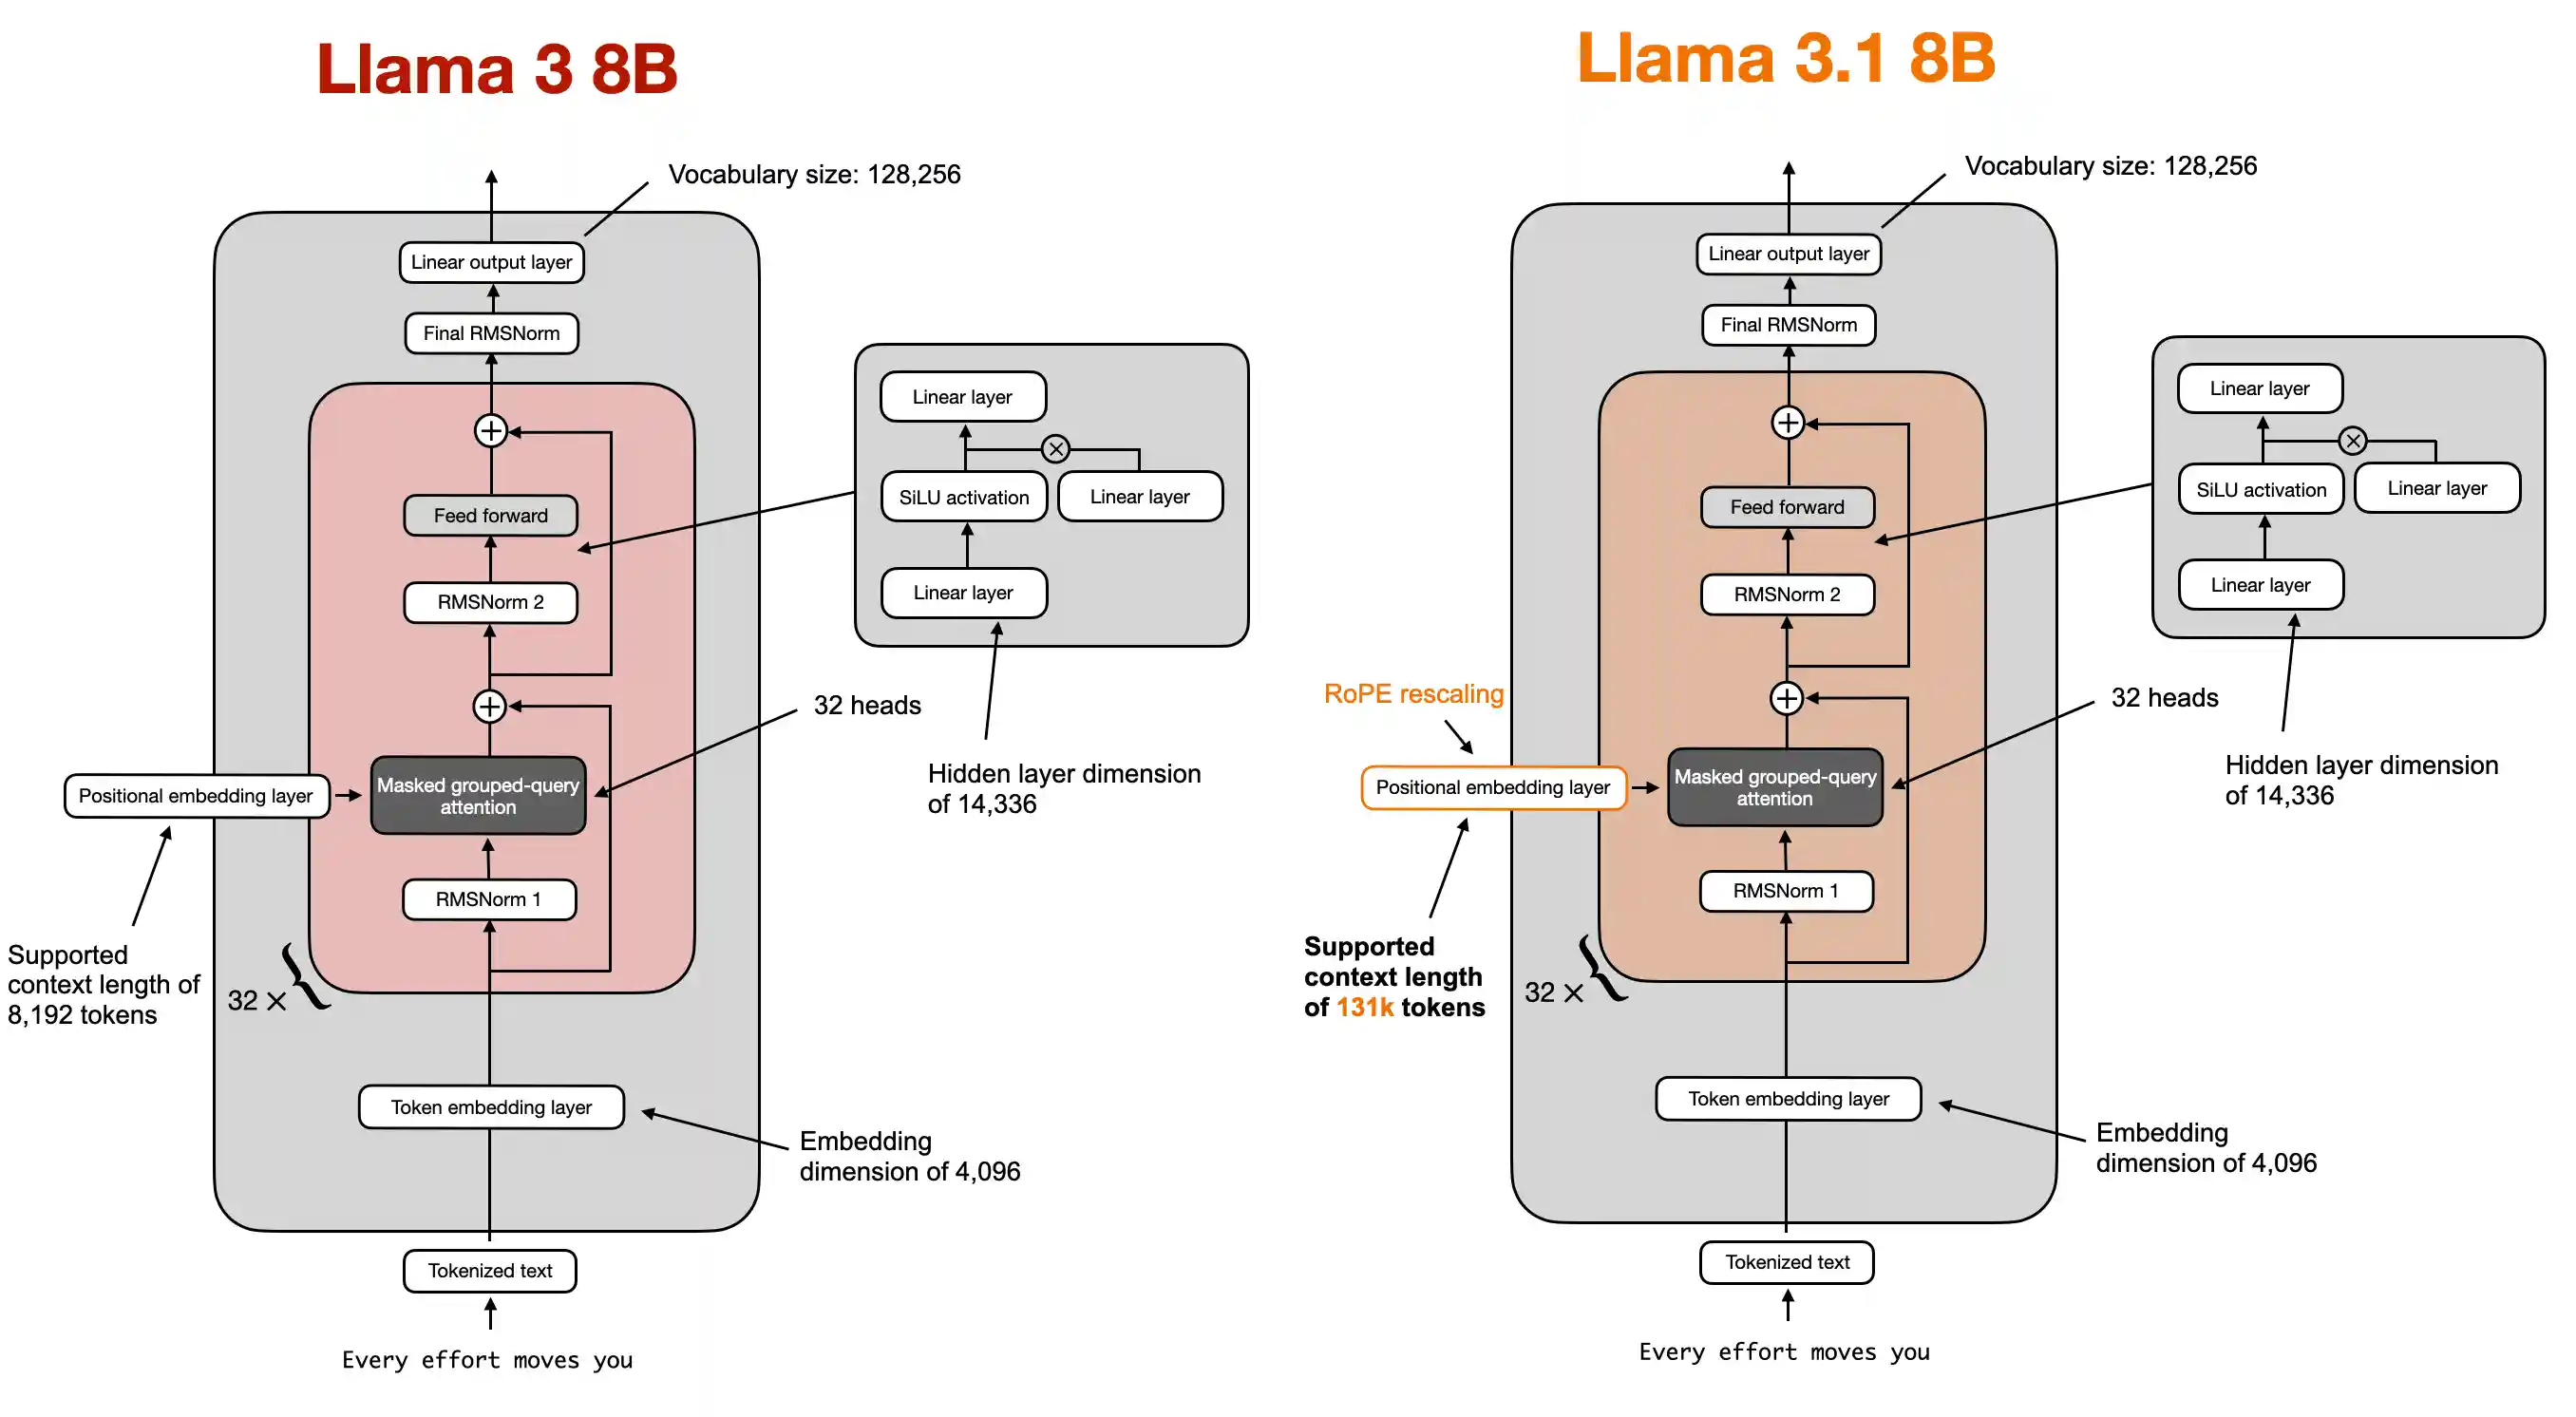

In [ ]:
# 重新列出 Llama3（初版）-8B 配置，作为与下面 Llama3.1-8B 配置的对比基准
LLAMA3_CONFIG_8B = {
    "vocab_size": 128_256,   # Vocabulary size
    "context_length": 8192,  # Context length
    "emb_dim": 4096,         # Embedding dimension
    "n_heads": 32,           # Number of attention heads
    "n_layers": 32,          # Number of layers
    "hidden_dim": 14_336,    # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,        # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,  # The base in RoPE's "theta"
    "rope_freq": None,       # Additional configuration for adjusting the RoPE frequencies
    "dtype": torch.bfloat16  # Lower-precision dtype to reduce memory usage
}

# Llama3.1-8B 配置：结构参数（层数、维度、KV 分组等）与 Llama3（初版）基本相同，
# 最大的变化是上下文长度从 8192 大幅提升到 131,072，并新增 rope_freq 做长上下文频率缩放
LLAMA31_CONFIG_8B = {
    "vocab_size": 128_256,      # Vocabulary size
    "context_length": 131_072,  # NEW: Larger supported context length
    "emb_dim": 4096,            # Embedding dimension
    "n_heads": 32,              # Number of attention heads
    "n_layers": 32,             # Number of layers
    "hidden_dim": 14_336,       # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,           # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,     # The base in RoPE's "theta"
    "dtype": torch.bfloat16,    # Lower-precision dtype to reduce memory usage
    # factor/low_freq_factor/high_freq_factor/original_context_length 共同决定
    # precompute_rope_params 中如何对高低频维度做缩放，使原本按 8192 长度训练的 RoPE 能够外推到 131,072
    "rope_freq": {              # NEW: RoPE frequency scaling
        "factor": 8.0,
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}

In [ ]:
# 切换模型前先释放 Llama3（初版）模型占用的显存
# free up memory
del model

gc.collect()  # Run Python garbage collector

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# 下载 Llama-3.1-8B 对应的 tokenizer（词表与特殊 token 和 Llama3 系列保持一致）
tokenizer_file_path = hf_hub_download(
    repo_id="meta-llama/Llama-3.1-8B",
    filename="original/tokenizer.model",
    local_dir="Llama-3.1-8B"
)

tokenizer = Tokenizer(tokenizer_file_path)

In [ ]:
# 用 Llama3.1-8B 配置实例化模型；结构参数与 Llama3（初版）相同，参数总量基本一致，
# 主要区别体现在 RoPE 的频率缩放和支持的最大上下文长度
model = Llama3Model(LLAMA31_CONFIG_8B)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

In [ ]:
# 下载并加载 Llama3.1-8B 的权重分片，命名规则与 Llama3（初版）完全相同，
# 因此可以直接复用同一套 load_weights_into_llama 函数
combined_weights = {}

for i in range(1, 5):
    weights_file = hf_hub_download(
        repo_id="meta-llama/Llama-3.1-8B",
        filename=f"model-0000{i}-of-00004.safetensors",
        local_dir="Llama-3.1-8B"
    )
    current_weights = load_file(weights_file)
    combined_weights.update(current_weights)

load_weights_into_llama(model, LLAMA31_CONFIG_8B, combined_weights)
model.to(device);
del combined_weights  # free up memory

In [ ]:
# 用加载好权重的 Llama3.1-8B 做一次生成，验证长上下文 RoPE 缩放没有破坏短序列上的正常生成效果
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA31_CONFIG_8B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

7. Llama 3.2 1B
8. 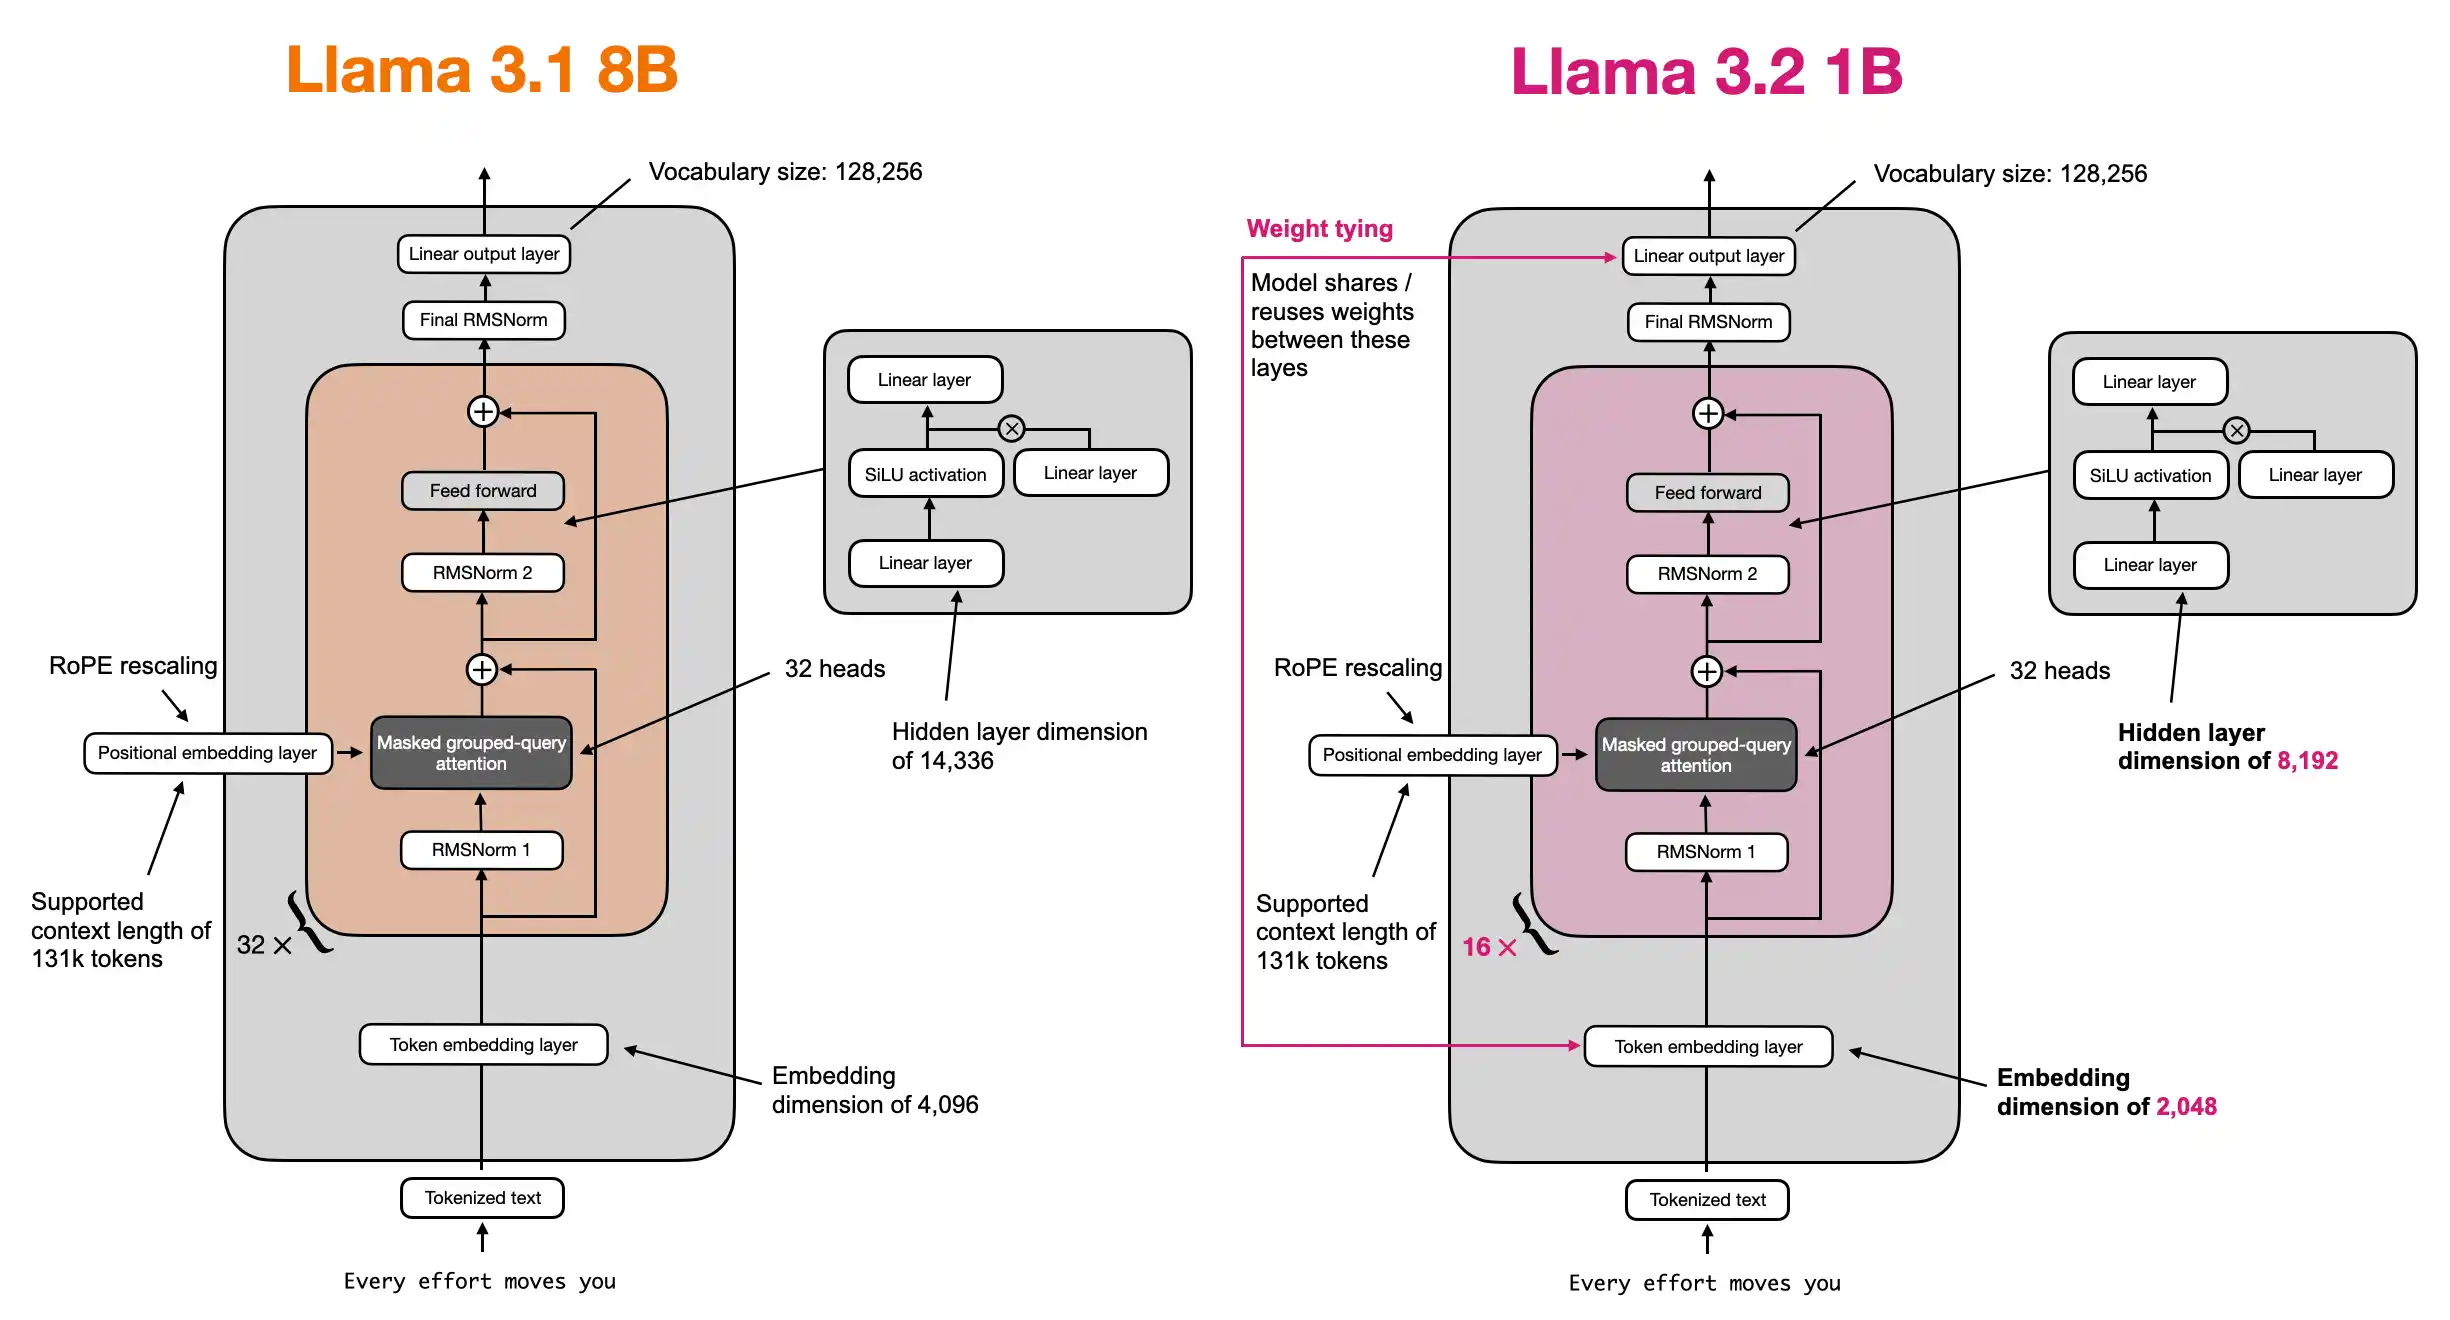

In [ ]:
LLAMA31_CONFIG_8B = {
    "vocab_size": 128_256,      # Vocabulary size
    "context_length": 131_072,  # NEW: Larger supported context length
    "emb_dim": 4096,            # Embedding dimension
    "n_heads": 32,              # Number of attention heads
    "n_layers": 32,             # Number of layers
    "hidden_dim": 14_336,       # Size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,           # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,     # The base in RoPE's "theta"
    "dtype": torch.bfloat16,    # Lower-precision dtype to reduce memory usagey
    "rope_freq": {              # NEW: RoPE frequency scaling
        "factor": 8.0,
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}


# Llama3.2-1B 配置：相比 Llama3.1-8B 大幅缩小模型规模——
# embedding 维度减半（4096->2048）、层数减半（32->16）、FeedForward 隐藏维度接近减半（14336->8192），
# 但仍保留 GQA（n_kv_groups=8）和相同的 131,072 超长上下文
LLAMA32_CONFIG_1B = {
    "vocab_size": 128_256,      # Vocabulary size
    "context_length": 131_072,  # Context length
    "emb_dim": 2048,            # NEW: Half the embedding dimension
    "n_heads": 32,              # Number of attention heads
    "n_layers": 16,             # NEW: Half the number of layers
    "hidden_dim": 8192,         # NEW: Almost half the size of the intermediate dimension in FeedForward
    "n_kv_groups": 8,           # Key-Value groups for grouped-query attention
    "rope_base": 500_000.0,     # The base in RoPE's "theta"
    "dtype": torch.bfloat16,    # Lower-precision dtype to reduce memory usage
    "rope_freq": {              # RoPE frequency scaling
        # 1B 模型把 RoPE 缩放因子 factor 从 Llama3.1-8B 的 8.0 进一步调大到 32.0，
        # 用于配合更小模型在同样 131,072 上下文下的频率外推
        "factor": 32.0,         # NEW: Adjustment of the rescaling factor
        "low_freq_factor": 1.0,
        "high_freq_factor": 4.0,
        "original_context_length": 8192,
    }
}

In [ ]:
# 切换到 Llama3.2-1B 之前，先释放上一个 Llama3.1-8B 模型
# free up memory
del model


gc.collect()  # Run Python garbage collector

if torch.cuda.is_available():
    torch.cuda.empty_cache()
# 下载 Llama-3.2-1B 对应的 tokenizer
tokenizer_file_path = hf_hub_download(
    repo_id="meta-llama/Llama-3.2-1B",
    filename="original/tokenizer.model",
    local_dir="Llama-3.2-1B"
)

tokenizer = Tokenizer(tokenizer_file_path)

In [ ]:
# 用 Llama3.2-1B 配置实例化模型
model = Llama3Model(LLAMA32_CONFIG_1B)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

# Account for weight tying
# Llama3.2-1B 使用了权重绑定（输出层与词嵌入共享参数），若把两部分参数都计入总数会重复计算，
# 这里减去一份词嵌入的参数量得到真实唯一参数量
total_params_normalized = total_params - model.tok_emb.weight.numel()
print(f"\nTotal number of unique parameters: {total_params_normalized:,}")

In [ ]:
# 另一种更通用的去重统计方式：通过比较参数张量的底层内存地址（data_ptr）判断是否为共享（绑定）权重，
# 不依赖手动减去某个具体模块的参数量
def count_unique_parameters(model):
    unique_params = set()
    total_unique_params = 0

    for param in model.parameters():
        if param.data_ptr() not in unique_params:
            total_unique_params += param.numel()
            unique_params.add(param.data_ptr())

    return total_unique_params

total_params_uniq = count_unique_parameters(model)
print(f"\nTotal number of unique parameters: {total_params_uniq:,}")

In [ ]:
# Llama-3.2-1B 权重体积较小，官方只发布了单个 safetensors 文件（不像 8B 模型那样分成 4 个分片）
weights_file = hf_hub_download(
    repo_id="meta-llama/Llama-3.2-1B",
    filename="model.safetensors",
    local_dir="Llama-3.2-1B"
)
current_weights = load_file(weights_file)

load_weights_into_llama(model, LLAMA32_CONFIG_1B, current_weights)
model.to(device);
del current_weights  # free up memory

In [ ]:
# 验证权重绑定：直接比较词嵌入权重与输出层权重的数值是否完全相等
# Checks that the weight values are the same
print("Weight tying:", torch.equal(model.tok_emb.weight, model.out_head.weight))

In [ ]:
# 进一步验证权重绑定：检查两者是否指向同一块底层内存（而非仅数值相等），确认是真正的参数共享而非简单复制
# Furthermore, check if PyTorch uses the same underlying memory
print("Weight tying:", model.tok_emb.weight.data_ptr() == model.out_head.weight.data_ptr())

In [ ]:
# 用加载好权重的 Llama3.2-1B 做最终生成测试
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort", tokenizer).to(device),
    max_new_tokens=25,
    context_size=LLAMA32_CONFIG_1B["context_length"],
    top_k=1,
    temperature=0.
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))